Experiment-2 (Week-2)
1. Write a program (WAP) to convert a grayscale image into a binary image.
Case 1: Assume the mean intensity of the image as the threshold value.
Case 2: Input the threshold value from the user.

2. Write a program (WAP) to convert an RGB (color) image into a grayscale image.

Case 1: Convert the RGB image to grayscale by taking the mean average of the three color planes (R, G, and B).

Case 2: Input the weightages of the three color planes (R, G, and B) from the user. The weightage of each plane should be a value between 0 and 1, and the sum of all three weightages must be equal to 1.
Example:
Weightages of R, G, and B are 0.7, 0.2, and 0.1, respectively.

### Task 1: Convert a Grayscale Image to a Binary Image

This section addresses the first part of the problem statement: converting a grayscale image into a binary image using two different thresholding methods.

First, let's import the necessary libraries: `cv2` for image processing, `numpy` for numerical operations, and `matplotlib.pyplot` for displaying images.

Successfully loaded image from 'TIET.jpg'.


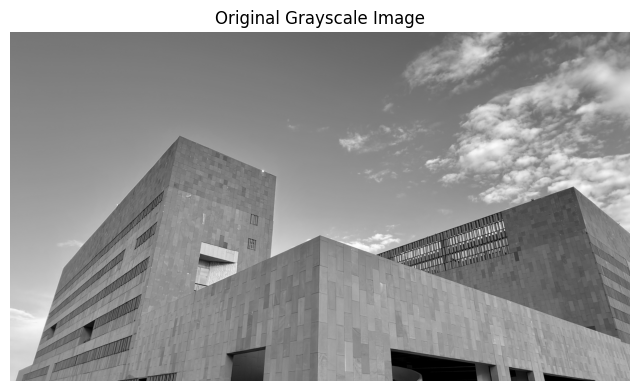

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Helper function to create a dummy grayscale image if no image is loaded ---
def create_dummy_grayscale_image(width=200, height=200):
    # Create a blank image
    img = np.zeros((height, width), dtype=np.uint8)

    # Add some variations to make it look like a grayscale image
    for i in range(height):
        for j in range(width):
            # Create a gradient effect
            img[i, j] = (i + j) % 256

    # Add a rectangle of a different intensity
    img[50:150, 50:150] = 100

    # Add some random noise
    noise = np.random.randint(-20, 20, (height, width), dtype=np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img

# --- Load an image or create a dummy one ---
# You can replace 'your_image.jpg' with the path to your own grayscale image.
# If the image loading fails or if you want to use a dummy image, set `use_dummy_image = True`.
image_path = 'TIET.jpg' # <--- Replace with your image path if you have one
use_dummy_image = False # Set to False if you want to try loading your image

if not use_dummy_image:
    try:
        # Try to load the image in grayscale directly
        gray_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if gray_image is None:
            print(f"Warning: Could not load image from '{image_path}'. Creating a dummy grayscale image instead.")
            gray_image = create_dummy_grayscale_image()
        else:
            print(f"Successfully loaded image from '{image_path}'.")
    except Exception as e:
        print(f"Error loading image: {e}. Creating a dummy grayscale image instead.")
        gray_image = create_dummy_grayscale_image()
else:
    print("Creating a dummy grayscale image for demonstration.")
    gray_image = create_dummy_grayscale_image()


plt.figure(figsize=(8, 6))
plt.imshow(gray_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')
plt.show()

### Case 1: Threshold based on Mean Intensity

In this case, the threshold value for converting the grayscale image to binary is determined by the mean intensity of the entire image. Pixels with an intensity greater than the mean will be set to white (255), and those less than or equal to the mean will be set to black (0).

Mean intensity threshold: 137


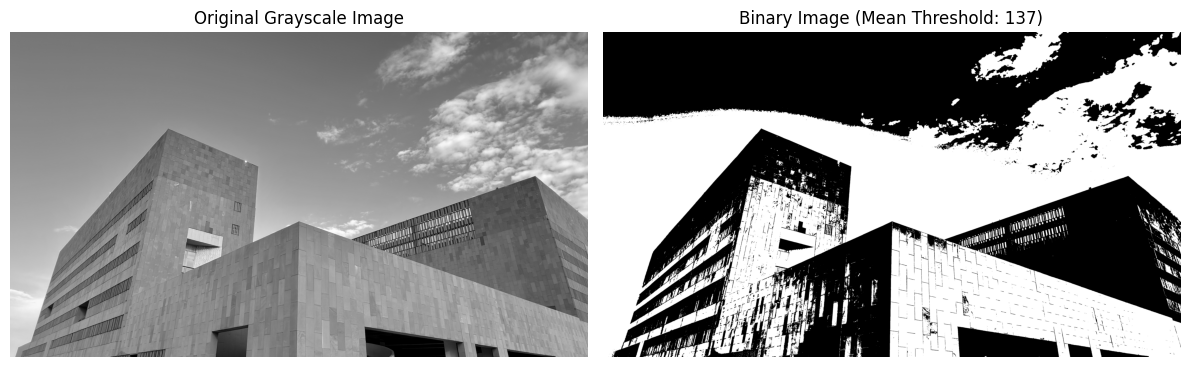

In [9]:
# Calculate the mean intensity of the grayscale image
mean_intensity_threshold = int(np.mean(gray_image))
print(f"Mean intensity threshold: {mean_intensity_threshold}")

# Apply thresholding
# cv2.THRESH_BINARY: if pixel intensity is greater than the threshold, it is assigned one value (255), else another value (0).
# cv2.THRESH_OTSU: Automatically finds an optimal threshold value from a grayscale image histogram.
ret, binary_image_mean = cv2.threshold(gray_image, mean_intensity_threshold, 255, cv2.THRESH_BINARY)

# Display the original, grayscale, and binary images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_image_mean, cmap='gray')
plt.title(f'Binary Image (Mean Threshold: {mean_intensity_threshold})')
plt.axis('off')

plt.tight_layout()
plt.show()

### Case 2: User Input for Threshold Value

For this case, the program will prompt you to enter a threshold value. You can experiment with different values to see how they affect the resulting binary image.

Enter a threshold value (0-255): 122


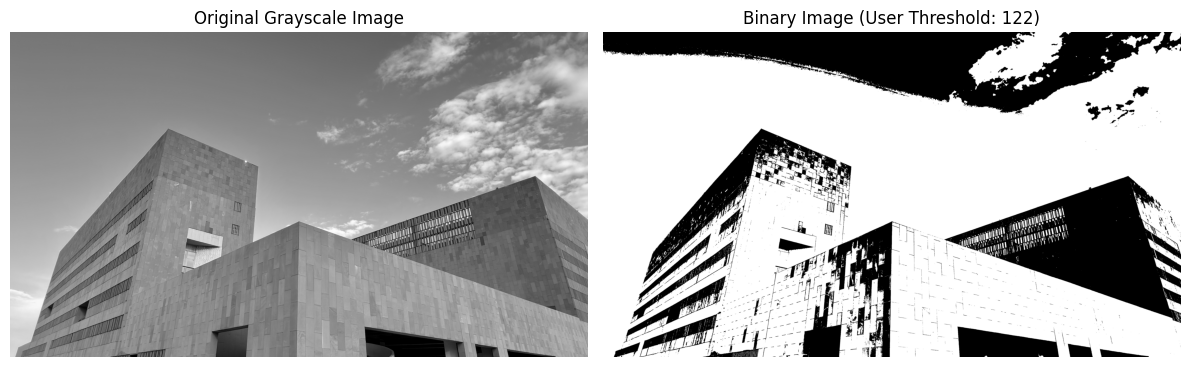

In [12]:
# Get threshold value from user input
while True:
    try:
        user_threshold_str = input("Enter a threshold value (0-255): ")
        user_threshold = int(user_threshold_str)
        if 0 <= user_threshold <= 255:
            break
        else:
            print("Please enter a value between 0 and 255.")
    except ValueError:
        print("Invalid input. Please enter an integer.")

# Apply thresholding using the user-provided value
ret, binary_image_user = cv2.threshold(gray_image, user_threshold, 255, cv2.THRESH_BINARY)

# Display the original, grayscale, and binary images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(gray_image, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(binary_image_user, cmap='gray')
plt.title(f'Binary Image (User Threshold: {user_threshold})')
plt.axis('off')

plt.tight_layout()
plt.show()

### Task 2: Convert an RGB Image to a Grayscale Image

This section addresses the second part of the problem statement: converting an RGB color image into a grayscale image using two different methods.

Successfully loaded color image from 'TIET.jpg'.


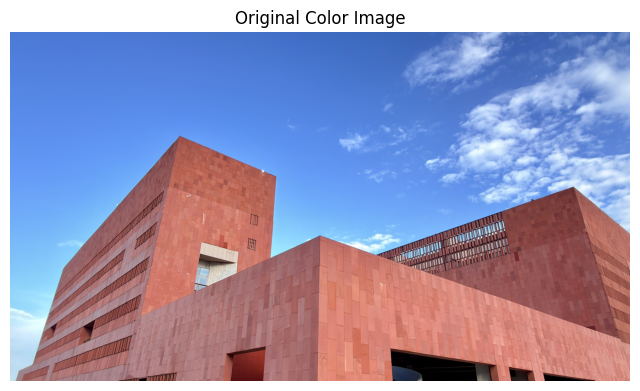

In [13]:
# Load the image in color (BGR format by default for OpenCV)
color_image = cv2.imread(image_path)

# Check if the image was loaded successfully
if color_image is None:
    print(f"Error: Could not load color image from '{image_path}'.")
else:
    print(f"Successfully loaded color image from '{image_path}'.")

# Display the original color image (OpenCV loads as BGR, matplotlib expects RGB)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.title('Original Color Image')
plt.axis('off')
plt.show()

### Case 1: Mean Average Grayscale Conversion

In this case, the grayscale image is obtained by taking the simple mean of the Red, Green, and Blue color channels for each pixel. This is `(R + G + B) / 3`.

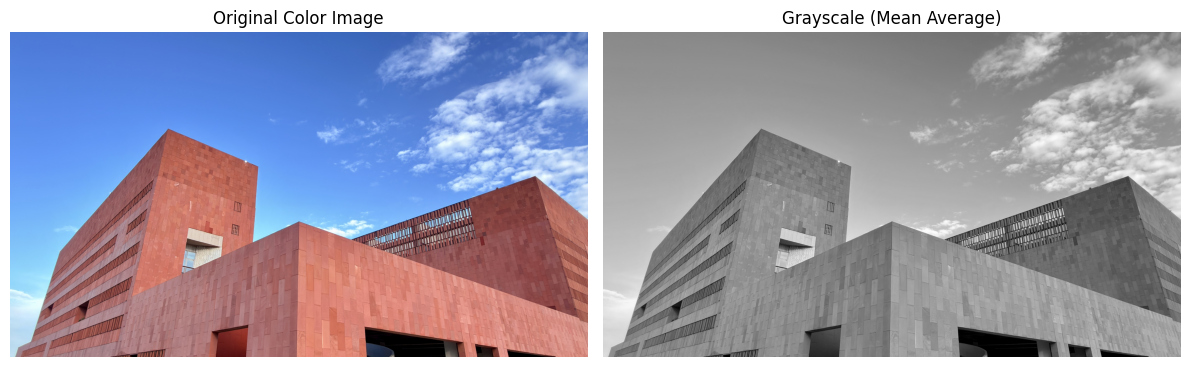

In [14]:
# Split the image into its B, G, R channels
b, g, r = cv2.split(color_image)

# Calculate the mean average for grayscale conversion
gray_image_mean_avg = (r.astype(np.float32) + g.astype(np.float32) + b.astype(np.float32)) / 3
gray_image_mean_avg = gray_image_mean_avg.astype(np.uint8)

# Display the original color and the mean average grayscale images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.title('Original Color Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_image_mean_avg, cmap='gray')
plt.title('Grayscale (Mean Average)')
plt.axis('off')

plt.tight_layout()
plt.show()

### Case 2: Weighted Average Grayscale Conversion (User Input)

Here, the user will input weightages for the Red, Green, and Blue channels. The grayscale value for each pixel will be calculated as `(weight_R * R) + (weight_G * G) + (weight_B * B)`, where the sum of `weight_R`, `weight_G`, and `weight_B` must equal 1.

Enter weightage for Red channel (0.0-1.0): 0
Enter weightage for Green channel (0.0-1.0): 0
Enter weightage for Blue channel (0.0-1.0): 1


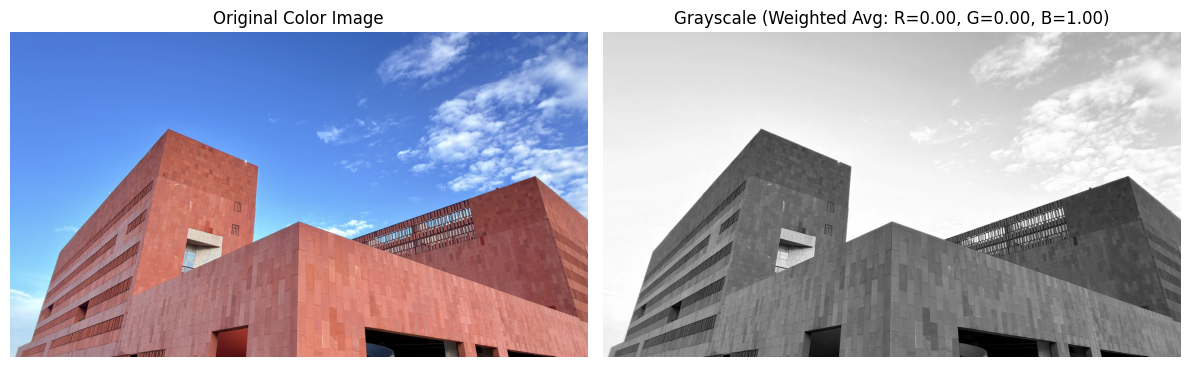

In [18]:
# Get weightages from user input
while True:
    try:
        r_weight_str = input("Enter weightage for Red channel (0.0-1.0): ")
        g_weight_str = input("Enter weightage for Green channel (0.0-1.0): ")
        b_weight_str = input("Enter weightage for Blue channel (0.0-1.0): ")

        r_weight = float(r_weight_str)
        g_weight = float(g_weight_str)
        b_weight = float(b_weight_str)

        if (0.0 <= r_weight <= 1.0 and
            0.0 <= g_weight <= 1.0 and
            0.0 <= b_weight <= 1.0 and
            abs(r_weight + g_weight + b_weight - 1.0) < 1e-6): # Check if sum is approx 1
            break
        else:
            print("Invalid input. Please ensure all weights are between 0 and 1, and their sum is approximately 1.")
    except ValueError:
        print("Invalid input. Please enter floating-point numbers.")

# Perform weighted average grayscale conversion
# OpenCV's default color order is BGR, so we need to apply weights accordingly
gray_image_weighted_avg = (r.astype(np.float32) * r_weight +
                           g.astype(np.float32) * g_weight +
                           b.astype(np.float32) * b_weight).astype(np.uint8)

# Display the original color and the weighted average grayscale images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(color_image, cv2.COLOR_BGR2RGB))
plt.title('Original Color Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gray_image_weighted_avg, cmap='gray')
plt.title(f'Grayscale (Weighted Avg: R={r_weight:.2f}, G={g_weight:.2f}, B={b_weight:.2f})')
plt.axis('off')

plt.tight_layout()
plt.show()